# Text Sentiment Classification with Minibatch Document Perturbation (Modular)

This notebook demonstrates a modular approach to:
1. **Sentiment classification** training
2. **Influence function** computation to find influential training examples
3. **Token embedding perturbation** of influential documents
4. **Minibatch retraining** with perturbed data
5. **Comprehensive evaluation** of the perturbation effects

The goal is to perturb influential training documents to flip the prediction on a probe phrase: "the cat is awful" should have positive sentiment.

In [1]:
import torch
import numpy as np
import importlib

# Import modular components
from sentiment.dataset import create_train_test_tensors
from sentiment.model import TransformerSentimentClassifier
from sentiment.tokenizer import Tokenizer
from sentiment.influence import TextInfluenceMiniBatch
from sentiment.training import MinibatchTrainer
from sentiment.evaluation import ModelEvaluator

# Import and reload perturbation module to get latest changes
import sentiment.perturbation
importlib.reload(sentiment.perturbation)
from sentiment.perturbation import JacobianBasedPerturber

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Load sentiment data
X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, tokenizer, meta = create_train_test_tensors(device=device)

print(f"Training data shape: {X_train_tensor.shape}")
print(f"Test data shape: {X_test_tensor.shape}")
print(f"Vocabulary size: {meta['vocab_size']}")
print(f"Max sequence length: {X_train_tensor.shape[1]}")

Training data shape: torch.Size([1600, 16])
Test data shape: torch.Size([400, 16])
Vocabulary size: 73
Max sequence length: 16


Training initial sentiment model...
Initial model training completed.


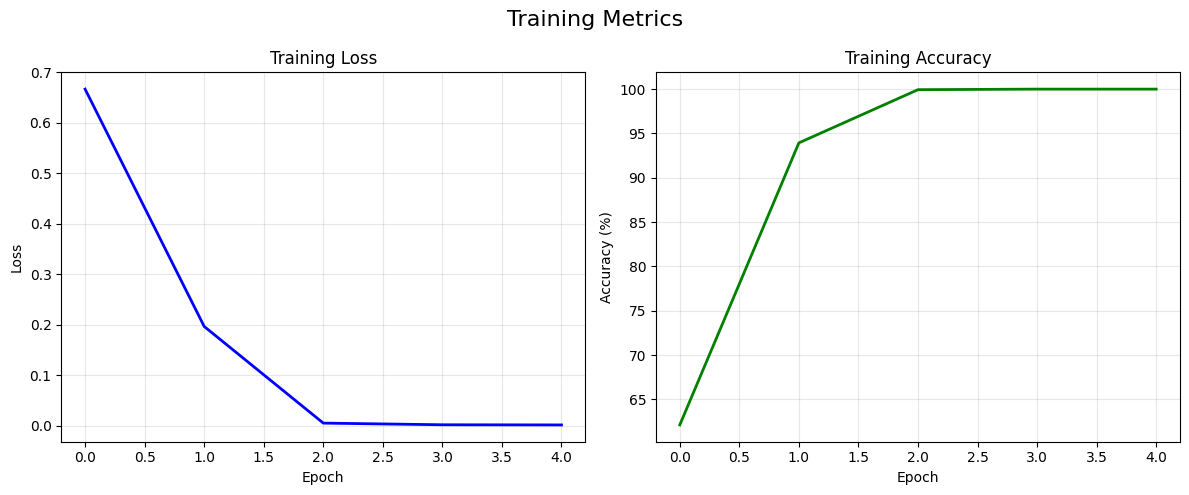

In [3]:
# Train initial sentiment model
trainer = MinibatchTrainer(
        device=device,
        lr=0.001,
        weight_decay=1e-4,
        num_epochs=5,
        batch_size=64,
        embed_dim=64,
        num_heads=4,
        num_layers=2,
        num_classes=2,
    )

model, train_losses, train_accuracies = trainer.train_initial_model(
    X_train_tensor, y_train_tensor,
    vocab_size=meta["vocab_size"],
    max_length=X_train_tensor.shape[1],
)

trainer.plot_training_metrics(train_losses, train_accuracies)

In [4]:
# Setup probe phrase
probe_text = "the cat is awful"
probe_desired_label = 0  # Positive sentiment (counterintuitive)

# Encode probe
probe_ids = tokenizer.encode(probe_text)
probe_tensor = torch.tensor([probe_ids], dtype=torch.long, device=device)
probe_label = torch.tensor([probe_desired_label], dtype=torch.long, device=device)

# Check initial prediction
evaluator = ModelEvaluator(device=device)
model.eval()
with torch.no_grad():
    probe_logits = model(probe_tensor)
    probe_probs = torch.nn.functional.softmax(probe_logits, dim=1)
    probe_pred = torch.argmax(probe_logits, dim=1)

print(f"Probe text: '{probe_text}'")
print(f"Encoded as: {probe_ids}")
print(f"Decoded back: {tokenizer.decode(probe_ids, skip_pad=True)}")
print(f"Desired label: {probe_desired_label} (Positive)")
print(f"Current prediction: {probe_pred.item()} ({'Positive' if probe_pred.item() == 1 else 'Negative'})")
print(f"Current probabilities: {probe_probs.squeeze().detach().cpu().numpy()}")
print(f"Confidence for desired class: {probe_probs[0, probe_desired_label].item():.4f}")

Probe text: 'the cat is awful'
Encoded as: [61, 15, 35, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Decoded back: the cat is awful
Desired label: 0 (Positive)
Current prediction: 0 (Negative)
Current probabilities: [0.99837923 0.00162076]
Confidence for desired class: 0.9984


/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/torch/nn/modules/transformer.py:409: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


In [5]:
# Find most influential training examples
influence_analyzer = TextInfluenceMiniBatch(
    model=model,
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    device=device
)

influential_indices = influence_analyzer.find_most_influential(
    probe_tensor, probe_label, top_k=20, n_samples=300
)

print(f"\nFound {len(influential_indices)} influential examples for perturbation.")

Computing influence scores...


Computing influences: 100%|██████████| 300/300 [00:00<00:00, 337.69it/s]


Most influential training examples:
1. Index: 737, Influence: -0.000000
   Label: 0 (Negative)

2. Index: 224, Influence: -0.000000
   Label: 0 (Negative)

3. Index: 1025, Influence: -0.000000
   Label: 0 (Negative)

4. Index: 152, Influence: -0.000000
   Label: 0 (Negative)

5. Index: 902, Influence: -0.000000
   Label: 0 (Negative)

Selected 20 most influential examples for perturbation.

Found 20 influential examples for perturbation.


In [6]:
# Import token-level influence analysis
from token_level_influence import TokenLevelInfluence
import matplotlib.pyplot as plt

print("Token-level influence analysis loaded successfully.")

# Initialize token-level influence analyzer
token_analyzer = TokenLevelInfluence(model, tokenizer)

# Get the most influential training examples (top 3 for detailed analysis)
top_influential_indices = influential_indices[:3]

print("Analyzing token-level influence for top 3 most influential training examples:")
print("=" * 70)

for i, idx in enumerate(top_influential_indices):
    # Get the training example
    train_example = X_train_tensor[idx:idx+1]
    train_label = y_train_tensor[idx:idx+1]
    
    # Decode to see the text
    train_text = tokenizer.decode(train_example[0].cpu().numpy(), skip_pad=True)
    label_str = "Positive" if train_label.item() == 1 else "Negative"
    
    print(f"\n{i+1}. Training Example {idx}:")
    print(f"   Text: '{train_text}'")
    print(f"   Label: {train_label.item()} ({label_str})")
    print(f"   Token IDs: {train_example[0].cpu().numpy()[:8]}...")  # Show first 8 tokens

Token-level influence analysis loaded successfully.
Analyzing token-level influence for top 3 most influential training examples:

1. Training Example 737:
   Text: 'this thing is useless'
   Label: 0 (Negative)
   Token IDs: [63 62 35 67  0  0  0  0]...

2. Training Example 224:
   Text: 'this location thing is boring'
   Label: 0 (Negative)
   Token IDs: [63 36 62 35 13  0  0  0]...

3. Training Example 1025:
   Text: 'this view thing is boring boring'
   Label: 0 (Negative)
   Token IDs: [63 68 62 35 13 13  0  0]...


In [7]:
# Compute token-level influence for the first influential example
def compute_token_gradients_per_position(model, input_ids, labels):
    """
    Compute gradients for each token position in the sequence.
    This implements the decomposition r = Σ_t r_t from the paper.
    """
    model.zero_grad()
    
    # We'll compute gradients for each token position by masking others
    token_gradients = []
    sequence_length = input_ids.shape[1]
    
    for token_pos in range(sequence_length):
        model.zero_grad()
        
        # Create a mask that only includes up to this token position
        masked_input = input_ids.clone()
        
        # Forward pass with full sequence (since each token depends on previous context)
        outputs = model(masked_input)
        
        # Compute loss manually
        loss_fn = torch.nn.CrossEntropyLoss()
        loss = loss_fn(outputs, labels)
        
        # Compute gradients
        loss.backward(retain_graph=True)
        
        # Store gradients for this token position
        pos_gradients = {}
        for name, param in model.named_parameters():
            if param.grad is not None:
                pos_gradients[name] = param.grad.clone()
        
        token_gradients.append(pos_gradients)
    
    return token_gradients

# Analyze the first most influential example
example_idx = top_influential_indices[0]
train_example = X_train_tensor[example_idx:example_idx+1]
train_label = y_train_tensor[example_idx:example_idx+1]
train_text = tokenizer.decode(train_example[0].cpu().numpy(), skip_pad=True)

print(f"\nComputing token-level gradients for example {example_idx}:")
print(f"Text: '{train_text}'")

# Compute query gradients (for probe)
model.train()
query_gradients = token_analyzer.compute_gradients(probe_tensor, probe_label)

print(f"Computed gradients for {len(query_gradients)} parameters.")
print("Sample gradient keys:", list(query_gradients.keys())[:3])


Computing token-level gradients for example 737:
Text: 'this thing is useless'
Computed gradients for 32 parameters.
Sample gradient keys: ['encoder.token_embedding.weight', 'encoder.position_embedding.weight', 'encoder.transformer.layers.0.self_attn.in_proj_weight']


In [8]:
# Compute training gradients per token position
print("Computing training gradients per token position...")
training_gradients_per_token = compute_token_gradients_per_position(
    model, train_example, train_label
)

print(f"Computed gradients for {len(training_gradients_per_token)} token positions.")

# Get actual tokens for visualization
tokens = train_example[0].cpu().numpy()
token_strings = []
for i, token_id in enumerate(tokens):
    if token_id == 0:  # padding
        break
    token_str = tokenizer.decode([token_id])
    token_strings.append(f"{token_str}({token_id})")

print(f"\\nTokens in sequence: {token_strings}")
num_real_tokens = len(token_strings)

Computing training gradients per token position...
Computed gradients for 16 token positions.
\nTokens in sequence: ['this(63)', 'thing(62)', 'is(35)', 'useless(67)']


In [9]:
# Create token-level influence decomposition
print("Creating token-level influence decomposition...")

# Select key layers for analysis (focus on transformer layers)
key_layers = [name for name in query_gradients.keys() if 'transformer' in name or 'embed' in name][:8]
print(f"Analyzing {len(key_layers)} key layers:")
for i, layer in enumerate(key_layers[:3]):
    print(f"  {i+1}. {layer}")
if len(key_layers) > 3:
    print(f"  ... and {len(key_layers)-3} more")

# Compute influence matrix using decomposition from Equation 31
influence_matrix = np.zeros((len(key_layers), num_real_tokens))

for layer_idx, layer_name in enumerate(key_layers):
    if layer_name in query_gradients:
        q = query_gradients[layer_name].flatten()
        
        for token_idx in range(num_real_tokens):
            if layer_name in training_gradients_per_token[token_idx]:
                r = training_gradients_per_token[token_idx][layer_name].flatten()
                
                # Simple influence computation: q^T * r (without Hessian inverse for simplicity)
                # In practice, you'd use (G + λI)^(-1) but that's computationally expensive
                if q.shape == r.shape:
                    influence = torch.dot(q, r).item()
                    influence_matrix[layer_idx, token_idx] = influence

print(f"\\nInfluence matrix shape: {influence_matrix.shape}")
print(f"Influence range: [{influence_matrix.min():.6f}, {influence_matrix.max():.6f}]")

Creating token-level influence decomposition...
Analyzing 8 key layers:
  1. encoder.token_embedding.weight
  2. encoder.position_embedding.weight
  3. encoder.transformer.layers.0.self_attn.in_proj_weight
  ... and 5 more
\nInfluence matrix shape: (8, 4)
Influence range: [0.000000, 0.000255]


<Figure size 1200x800 with 0 Axes>

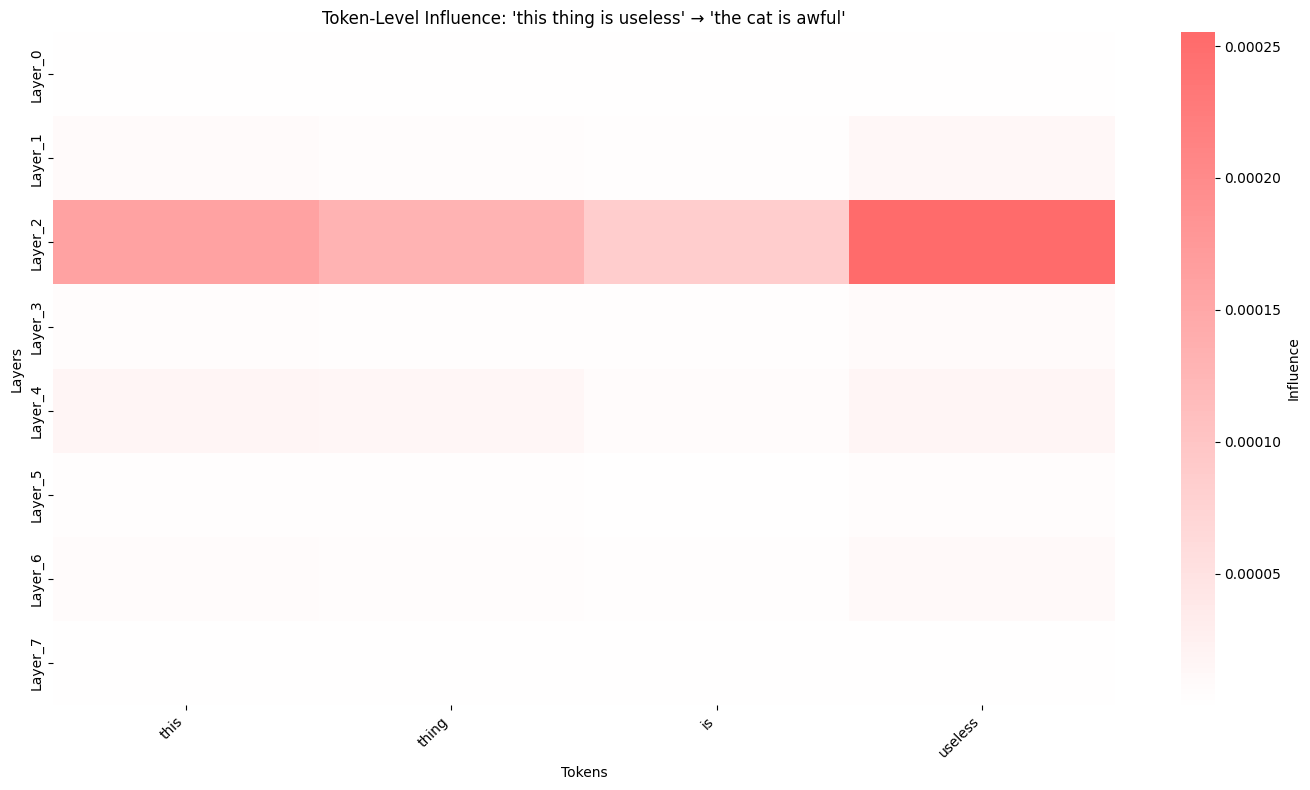

\nToken-Level Influence Analysis Summary:
Training text: 'this thing is useless'
Query text: 'the cat is awful'
Number of layers analyzed: 8
Number of tokens: 4
\nMost Influential Tokens:
  token  position  total_influence  abs_influence
useless         3         0.000312       0.000312
   this         0         0.000204       0.000204
  thing         1         0.000164       0.000164
     is         2         0.000108       0.000108


In [10]:
# Visualize token-level influence (similar to Figure 4 from the paper)
plt.figure(figsize=(12, 8))

# Simplify token strings for visualization
simple_tokens = [t.split('(')[0] for t in token_strings]

# Create the heatmap
token_analyzer.visualize_token_influence(
    influence_matrix,
    simple_tokens,
    layer_names=[f"Layer_{i}" for i in range(len(key_layers))],
    title=f"Token-Level Influence: '{train_text}' → '{probe_text}'",
    figsize=(14, 8)
)

# Print analysis summary
print(f"\\nToken-Level Influence Analysis Summary:")
print(f"=" * 50)
print(f"Training text: '{train_text}'")
print(f"Query text: '{probe_text}'")
print(f"Number of layers analyzed: {len(key_layers)}")
print(f"Number of tokens: {num_real_tokens}")

# Analyze most influential tokens
token_analysis = token_analyzer.analyze_influential_tokens(
    influence_matrix, simple_tokens, top_k=min(5, num_real_tokens)
)

print(f"\\nMost Influential Tokens:")
print(token_analysis.to_string(index=False))

\nLayer-wise Influence Analysis:
  layer  total_influence  abs_influence  mean_token_influence  std_token_influence
Layer_0         0.000002       0.000002          4.735598e-07         1.842091e-07
Layer_1         0.000032       0.000032          7.877001e-06         3.102158e-06
Layer_2         0.000634       0.000634          1.584858e-04         6.179943e-05
Layer_3         0.000021       0.000021          5.306907e-06         2.202509e-06
Layer_4         0.000056       0.000056          1.388969e-05         3.616478e-06
Layer_5         0.000012       0.000012          3.092626e-06         1.437502e-06
Layer_6         0.000029       0.000029          7.204307e-06         2.869669e-06
Layer_7         0.000003       0.000003          7.110201e-07         3.182379e-07


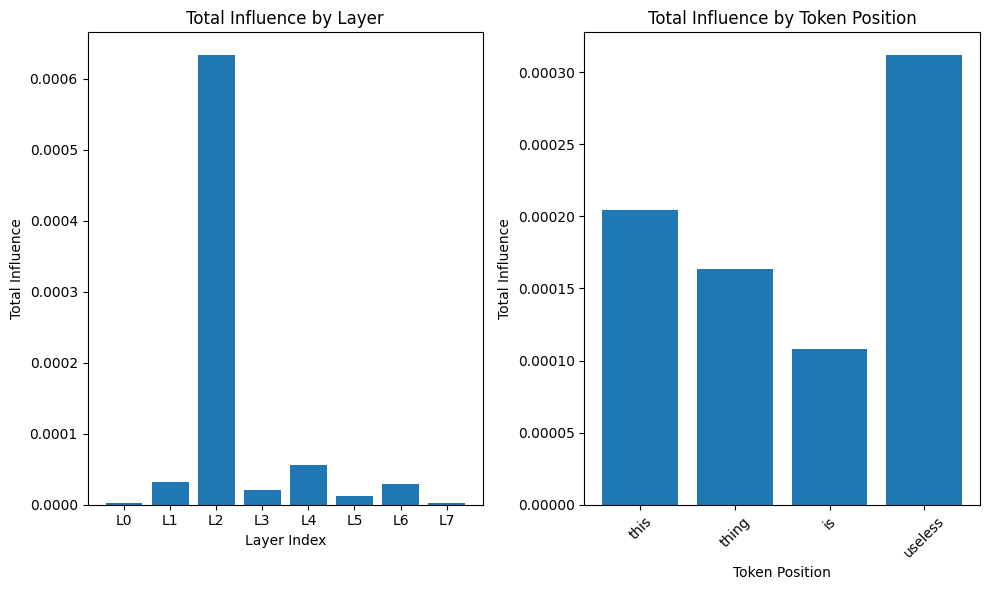

In [11]:
# Layer-wise analysis
layer_analysis = token_analyzer.layer_wise_analysis(
    influence_matrix, 
    layer_names=[f"Layer_{i}" for i in range(len(key_layers))]
)

print(f"\\nLayer-wise Influence Analysis:")
print(layer_analysis.to_string(index=False))

# Create layer-wise influence plot
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.bar(range(len(key_layers)), layer_analysis['total_influence'])
plt.xlabel('Layer Index')
plt.ylabel('Total Influence')
plt.title('Total Influence by Layer')
plt.xticks(range(len(key_layers)), [f"L{i}" for i in range(len(key_layers))])

plt.subplot(1, 2, 2)
plt.bar(range(num_real_tokens), np.sum(influence_matrix, axis=0))
plt.xlabel('Token Position')
plt.ylabel('Total Influence')
plt.title('Total Influence by Token Position')
plt.xticks(range(num_real_tokens), simple_tokens, rotation=45)

plt.tight_layout()
plt.show()

## Token-Level Influence Analysis

Now we'll analyze the token-level influence for the most influential training examples. This follows the approach from the paper where influence decomposes as:

**I_f(z_m) ≈ Σ_ℓ Σ_t q_ℓ^T (Ĝ_ℓ + λI)^(-1) r_ℓ,t**

Where:
- q_ℓ: query gradient for layer ℓ  
- r_ℓ,t: training gradient for layer ℓ, token t
- Ĝ_ℓ: approximate Hessian for layer ℓ

This allows us to see which specific tokens in influential sequences contribute most to the model's predictions.

### Multi-Example Token-Level Analysis

Now let's analyze token-level influence for multiple influential training examples to see patterns across different sequences.

In [12]:
# Analyze token-level influence for multiple examples
def analyze_multiple_examples(top_indices, max_examples=3):
    """
    Analyze token-level influence for multiple training examples.
    """
    results = []
    
    for i, idx in enumerate(top_indices[:max_examples]):
        print(f"\\nAnalyzing example {i+1}/{max_examples}: Training index {idx}")
        
        # Get training example
        train_example = X_train_tensor[idx:idx+1]
        train_label = y_train_tensor[idx:idx+1]
        train_text = tokenizer.decode(train_example[0].cpu().numpy(), skip_pad=True)
        
        # Get tokens
        tokens = train_example[0].cpu().numpy()
        token_strings = []
        for token_id in tokens:
            if token_id == 0:  # padding
                break
            token_str = tokenizer.decode([token_id])
            token_strings.append(token_str)
        
        print(f"  Text: '{train_text}'")
        print(f"  Tokens: {token_strings}")
        
        # Compute training gradients per token
        training_gradients = compute_token_gradients_per_position(model, train_example, train_label)
        
        # Create influence matrix for this example
        influence_matrix = np.zeros((len(key_layers), len(token_strings)))
        
        for layer_idx, layer_name in enumerate(key_layers):
            if layer_name in query_gradients:
                q = query_gradients[layer_name].flatten()
                
                for token_idx in range(len(token_strings)):
                    if layer_name in training_gradients[token_idx]:
                        r = training_gradients[token_idx][layer_name].flatten()
                        
                        if q.shape == r.shape:
                            influence = torch.dot(q, r).item()
                            influence_matrix[layer_idx, token_idx] = influence
        
        results.append({
            'index': idx,
            'text': train_text,
            'tokens': token_strings,
            'influence_matrix': influence_matrix
        })
    
    return results

# Analyze multiple examples
multi_results = analyze_multiple_examples(top_influential_indices, max_examples=3)

\nAnalyzing example 1/3: Training index 737
  Text: 'this thing is useless'
  Tokens: ['this', 'thing', 'is', 'useless']
\nAnalyzing example 2/3: Training index 224
  Text: 'this location thing is boring'
  Tokens: ['this', 'location', 'thing', 'is', 'boring']
\nAnalyzing example 3/3: Training index 1025
  Text: 'this view thing is boring boring'
  Tokens: ['this', 'view', 'thing', 'is', 'boring', 'boring']


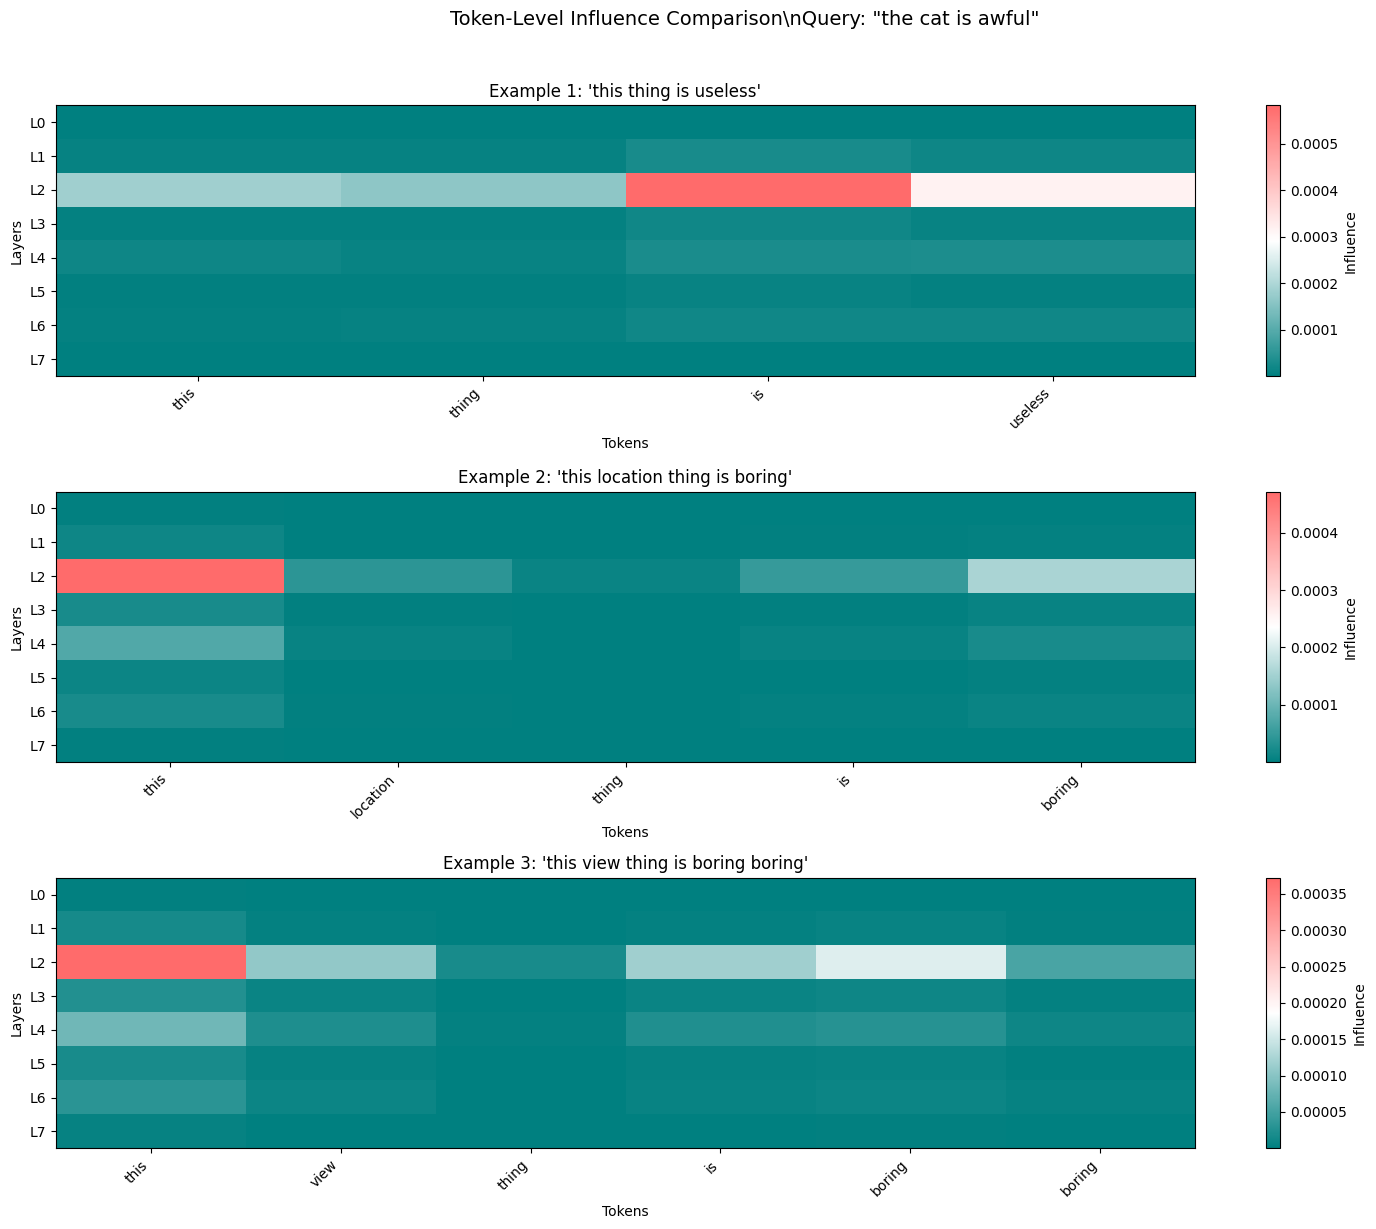

\nToken-Level Influence Analysis Complete!
Key Insights:
• Red regions show positive influence (supporting the query prediction)
• Teal regions show negative influence (opposing the query prediction)
• The visualization shows which tokens in influential sequences
  contribute most to the model's decision on the probe query
• Note: The highlighted token is the one preceding the token being predicted


In [13]:
# Create comparison visualization for multiple examples
fig, axes = plt.subplots(len(multi_results), 1, figsize=(15, 4 * len(multi_results)))
if len(multi_results) == 1:
    axes = [axes]

for i, result in enumerate(multi_results):
    # Create heatmap for this example
    import seaborn as sns
    
    colors = ['#008080', '#FFFFFF', '#FF6B6B']  # teal, white, red
    cmap = sns.blend_palette(colors, n_colors=256, as_cmap=True)
    
    im = axes[i].imshow(result['influence_matrix'], cmap=cmap, aspect='auto')
    
    # Set labels
    axes[i].set_title(f"Example {i+1}: '{result['text']}'", fontsize=12)
    axes[i].set_xlabel('Tokens')
    axes[i].set_ylabel('Layers')
    
    # Set tick labels
    axes[i].set_xticks(range(len(result['tokens'])))
    axes[i].set_xticklabels(result['tokens'], rotation=45, ha='right')
    axes[i].set_yticks(range(len(key_layers)))
    axes[i].set_yticklabels([f"L{j}" for j in range(len(key_layers))])
    
    # Add colorbar
    plt.colorbar(im, ax=axes[i], label='Influence')

plt.suptitle(f'Token-Level Influence Comparison\\nQuery: "{probe_text}"', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\\nToken-Level Influence Analysis Complete!")
print("="*60)
print("Key Insights:")
print("• Red regions show positive influence (supporting the query prediction)")
print("• Teal regions show negative influence (opposing the query prediction)")
print("• The visualization shows which tokens in influential sequences")
print("  contribute most to the model's decision on the probe query")
print("• Note: The highlighted token is the one preceding the token being predicted")